# Long vs. wide tables

or: using the pandas methods: pd.melt() and pd.pivot()

## Motivation

So far our dataframes showed all the different observations in rows and all their different features in columns:

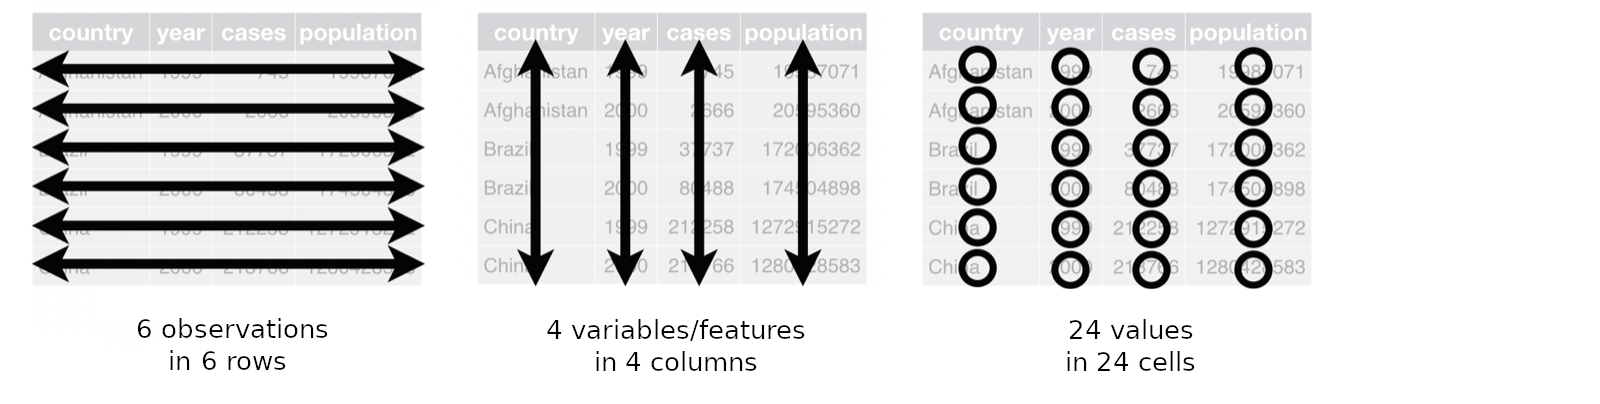

Let's assume we want to create an `sns.boxplot()` of the two culmen measurements while discriminating the Species.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
penguins_df = pd.read_csv('./data/penguins_simple.csv', sep=";")  # convert a csv file into a dataframe
penguins_df.head()

,Species,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex
0,Adelie,39.1,18.7,181.0,3750.0,MALE
1,Adelie,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,36.7,19.3,193.0,3450.0,FEMALE
4,Adelie,39.3,20.6,190.0,3650.0,MALE


We want a figure like this:  
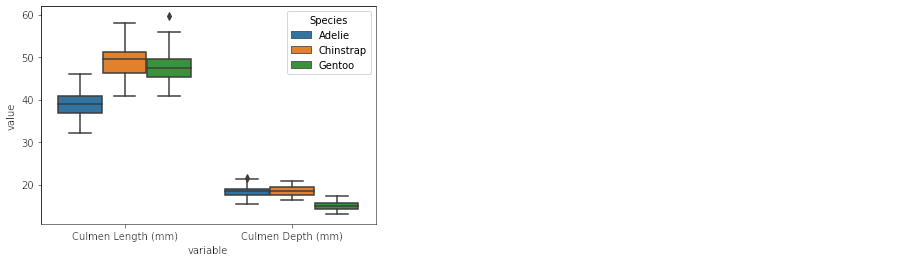

`sns.boxplot()` allows for these arguments:<br>
`sns.boxplot(data=..., x=..., y=..., hue=...)`  

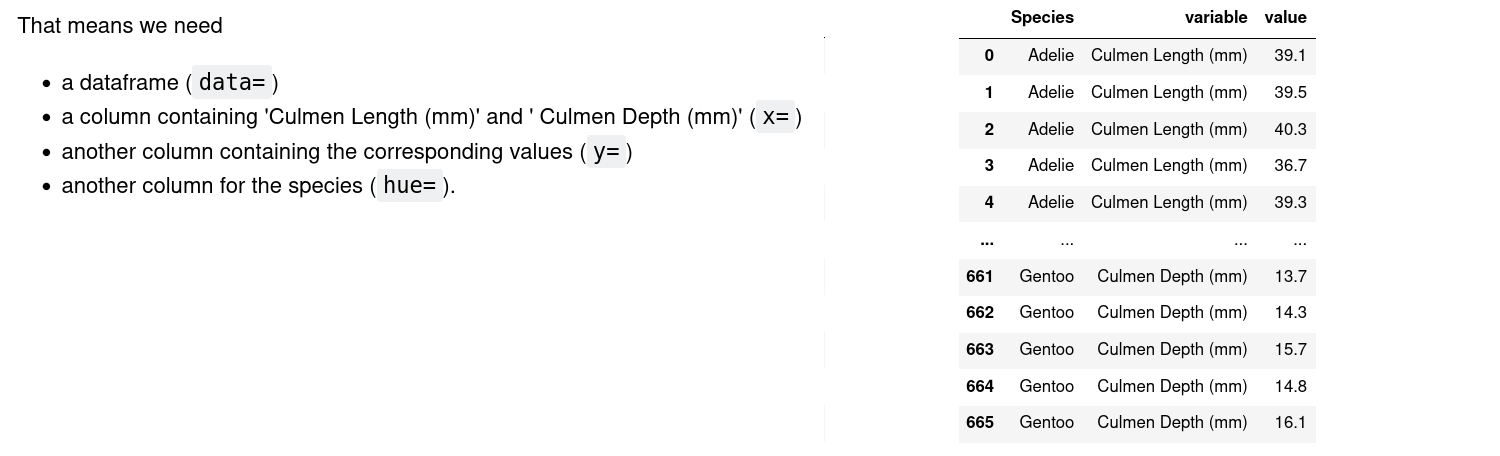

That's were the so-called **long format** comes in (in contrast to the known **wide format**).

- In the **wide format**, each feature has its own column. This format is great for calculating descriptive statistics or for applying machine learning with ```sklearn```.

- In the **long format**, there is a single value column containing the values for the different feature combinations and columns that contain the feature names stacked one below the other. This format is great for plotting, e.g. with ```seaborn```.

Today we learn to know how to convert between these formats..

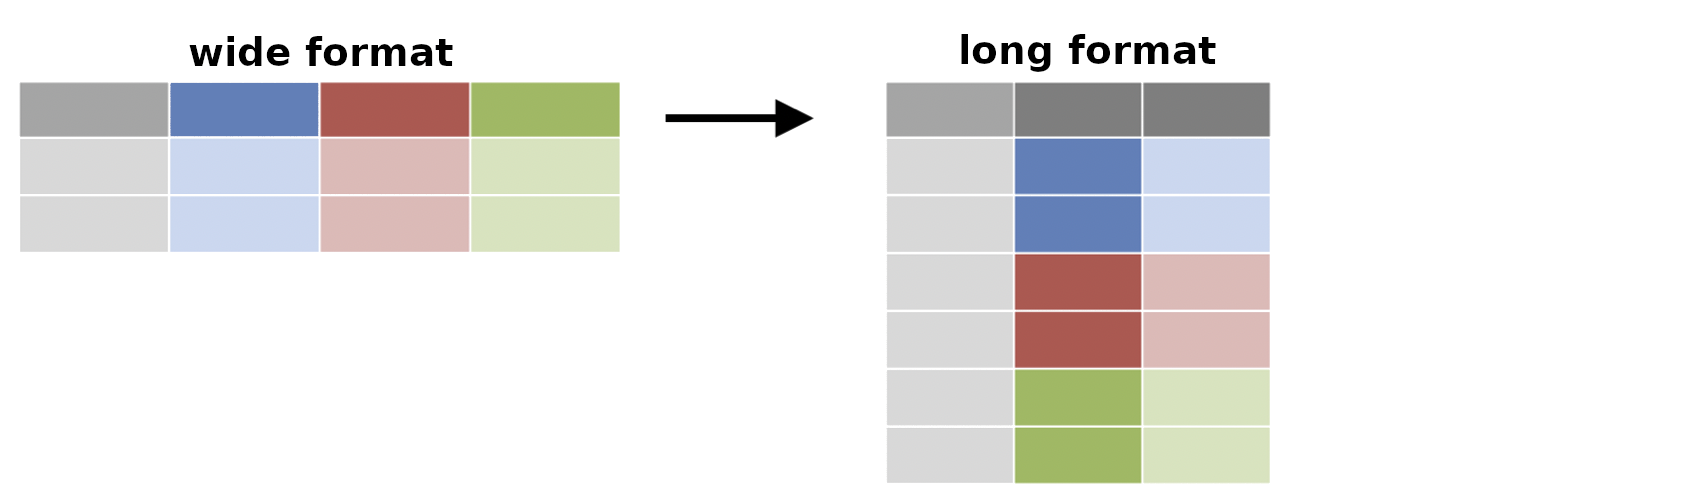

## Melting of the wide format into the long one

<img src='melting_growing_icicle.gif' width=60>

### How `df.melt()` works
(equivalent to `pd.melt(df)`)

#### Which arguments does [`df.melt`](https://pandas.pydata.org/docs/reference/api/pandas.melt.html) have?

`df.melt(id_vars=..., value_vars=..., var_name=..., value_name=...)`<br/><br/>
confusing naming ceremony? `variables` describe what it is about, while `values` are basically the numbers.

In [3]:
row1 = [1, 'a', 'b', 'c']
row2 = [2, 'd', 'e', 'f']

example_df = pd.DataFrame(data=[row1, row2], columns = ['id', 'no1', 'no2', 'no3'])
example_df

,id,no1,no2,no3
0,1,a,b,c
1,2,d,e,f


#### The argument `id_vars`

`id_vars`: the column which will appear in the resulting dataframe again after melting. Their values will appear repeated times.

In [4]:
example_df.melt(id_vars='id')

,id,variable,value
0,1,no1,a
1,2,no1,d
2,1,no2,b
3,2,no2,e
4,1,no3,c
5,2,no3,f


#### The argument `value_vars`

`value_vars`: limit the melted output to these columns of the original dataframe. (If not specified, all remaining columns will be used)

In [5]:
example_df.melt(id_vars='id', value_vars=['no2', 'no3'])  # "no1" will not appear in the resulting df

,id,variable,value
0,1,no2,b
1,2,no2,e
2,1,no3,c
3,2,no3,f


#### The arguments `var_name` and `value_name`

`var_`/`value_name`: to give the resulting columns self-selected names  

In [8]:
example_df.melt(id_vars='id', var_name='my_var_name', value_name='my_val_name', ignore_index=False)

,id,my_var_name,my_val_name
0,1,no1,a
1,2,no1,d
0,1,no2,b
1,2,no2,e
0,1,no3,c
1,2,no3,f


#### Let's solve the penguin boxplot task

In [9]:
penguins_df.head()

,Species,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex
0,Adelie,39.1,18.7,181.0,3750.0,MALE
1,Adelie,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,36.7,19.3,193.0,3450.0,FEMALE
4,Adelie,39.3,20.6,190.0,3650.0,MALE


In [18]:
melted_penguins = penguins_df.melt(id_vars='Species',
                                   value_vars=['Culmen Length (mm)', 'Culmen Depth (mm)'],
                                   ignore_index=False)
melted_penguins.sample(10)

,Species,variable,value
83,Adelie,Culmen Depth (mm),18.8
118,Adelie,Culmen Length (mm),35.2
44,Adelie,Culmen Depth (mm),17.7
196,Chinstrap,Culmen Depth (mm),16.4
108,Adelie,Culmen Depth (mm),20.7
10,Adelie,Culmen Depth (mm),17.8
96,Adelie,Culmen Depth (mm),16.0
163,Chinstrap,Culmen Length (mm),58.0
287,Gentoo,Culmen Depth (mm),16.0
139,Adelie,Culmen Depth (mm),18.7


<AxesSubplot:xlabel='variable', ylabel='value'>

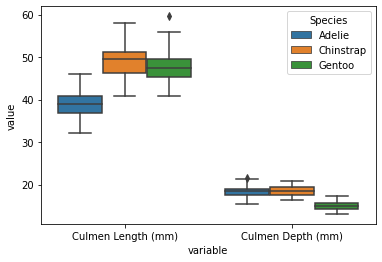

In [14]:
sns.boxplot(data=melted_penguins, x='variable', y='value', hue='Species')

## Pivoting of the long format into the wide one

If you have the opposite problem, the reverse operation can be performed with [`df.pivot()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.pivot.html)   
*Pivot* means rotation point. (The term is of french unknown origin.)

#### Which arguments does `df.pivot()` have?

`df.pivot(index=..., columns=..., values=...)`  
- Which column should be the `index` of the new wide dataframe if we don't want it to be the current index
- Which column from the long table should become separate `columns`,
- Which column we want to use as the `values` to populate the wide table

#### Let's reconsider our example dataframe

In [19]:
melted_example = example_df.melt(id_vars='id', 
                                 var_name='my_var_name', value_name='my_value_name',
                                 ignore_index=False)
melted_example

,id,my_var_name,my_value_name
0,1,no1,a
1,2,no1,d
0,1,no2,b
1,2,no2,e
0,1,no3,c
1,2,no3,f


*Sidenote:* If you want the index renumbered (without creating a new column), use: `melted_example.reset_index(drop=True)`

Undoing the melting

In [46]:
reverted_df = melted_example.pivot(index='id', columns='my_var_name', values='my_value_name')
reverted_df

my_var_name,no1,no2,no3
id,,,
1,a,b,c
2,d,e,f


*Sidenote:* If you want to get rid of the additional names:

In [47]:
reverted_df.columns.name = ''
reverted_df.index.name = 'id'

In [48]:
reverted_df

,no1,no2,no3
id,,,
1,a,b,c
2,d,e,f


In [49]:
reverted_df.reset_index(inplace=True)
reverted_df

,id,no1,no2,no3
0,1,a,b,c
1,2,d,e,f


#### And the pivoting of our melted penguins

In [ ]:
melted_penguins.pivot(index='Species', columns='variable', values='value')

Gives an error. Think about why ...

In contrast to our simple example_df with unique identifiers for each observation in the `id` column, the `Species` column is all but unique. `pd.pivot()` cannot know, which rows of the long format correspond to each other. We lost the information by melting and would have been more clever to keep the penguins id as well before melting (`ignore_index=False` and/or `reset_index()`).

```
melted_penguins = penguins_df.melt(id_vars='Species',
                                   value_vars=['Culmen Length (mm)', 'Culmen Depth (mm)'],
                                   ignore_index=False)
melted_penguins.reset_index(inplace=True)
melted_penguins.pivot(index=['index', 'Species'], columns='variable', values='value')
```
or:
```
melted_penguins = penguins_df.reset_index().melt(id_vars=['index','Species'],
                                                 value_vars=['Culmen Length (mm)', 'Culmen Depth (mm)'])
melted_penguins.pivot(index=['index', 'Species'], columns='variable', values='value')
```

## Alternatives to `melt` and `pivot`

pandas offers several further methods for the conversions (which you might find useful as well).

- `pd.stack()` behaves similar to `pd.melt()` but uses the index as "`id_vars`".  
- `pd.unstack()` converts long into wide format, similar to `pd.pivot()`
- `pd.wide_to_long` if you want to use more than one column as identifier
- `pd.pivot_table()` if you additionally want to perform some aggregation<br>

Find out how to use those functions [here](https://pandas.pydata.org/docs/reference/frame.html) or have a look at the references below. They are not necessarily needed for the week's project.

## Tidy data: a mandatory requirement for DS

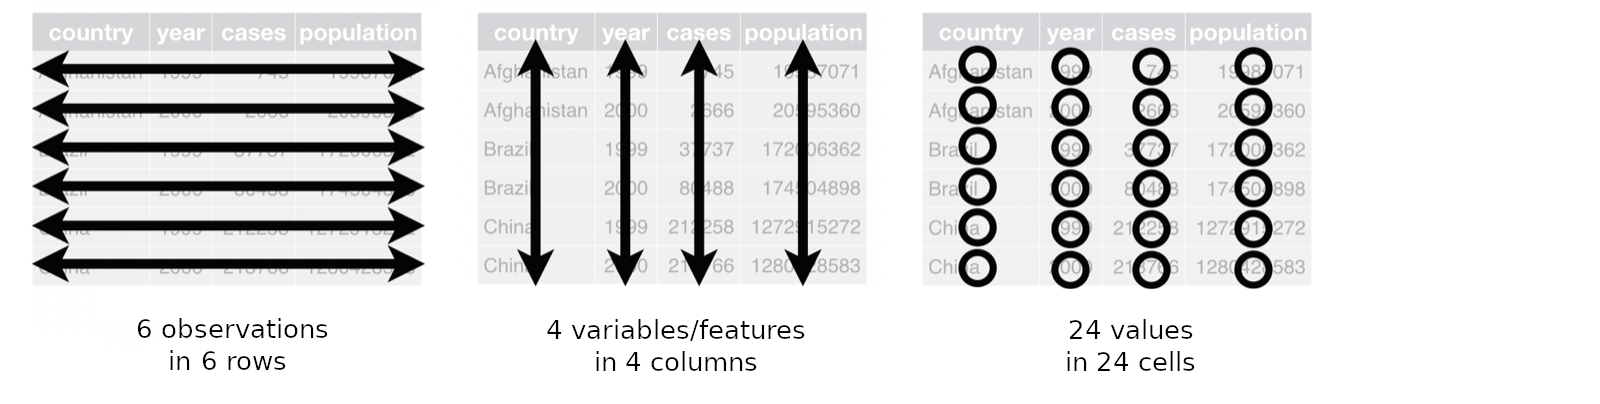

#### 😀 Tidy Data
- Each observation forms a **row**
- Each [statistical] variable/feature forms a **column**
- Each value gets its own **cell**
- Each type of observational unit forms a table

#### ❌ Messy Data
- Column headers are values, not variable names
- Multiple variables are stored in one column
- Single variable stored in different columns
- Single observation stored across multiple rows

*Sidenote:* From this point of view, the dataframe of our boxplot example is not tidy (different kinds of values, culmen length *and* depth, in one column) but better suited for plotting.

#### TIDY dataset example

In [55]:
sns.load_dataset('penguins').head()  # The dataset is part of seaborn.

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


##### What makes this data tidy?

- all the observations are rows
    - each row corresponds to one penguin
    - penguins are not split over multiple rows
- all the variables are in separate columns
- each cell contains one value

#### UNTIDY dataset example

In [56]:
life = pd.read_excel('./data/gapminder_lifeexpectancy.xlsx',index_col=0)

In [57]:
life.head()

,1800.0,1801.0,1802.0,1803.0,1804.0,1805.0,1806.0,1807.0,1808.0,1809.0,...,2007.0,2008.0,2009.0,2010.0,2011.0,2012.0,2013.0,2014.0,2015.0,2016.0
Life expectancy,,,,,,,,,,,,,,,,,,,,,
Abkhazia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Afghanistan,28.21,28.20,28.19,28.18,28.17,28.16,28.15,28.14,28.13,28.12,...,52.4,52.8,53.3,53.6,54.0,54.4,54.8,54.9,53.8,52.72
Akrotiri and Dhekelia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Albania,35.40,35.40,35.40,35.40,35.40,35.40,35.40,35.40,35.40,35.40,...,76.6,76.8,77.0,77.2,77.4,77.5,77.7,77.9,78.0,78.10
Algeria,28.82,28.82,28.82,28.82,28.82,28.82,28.82,28.82,28.82,28.82,...,75.3,75.5,75.7,76.0,76.1,76.2,76.3,76.3,76.4,76.50


What makes this dataset untidy and what do we need to fix?

- column names are numeric, the first one is a string with whitespace
    - could get rid of whitespace by renaming it 'country'
- the numeric column names should be converted to integers
- the years as column names are values, not variables - we need a new column called "year"
- could also remove (or fill &rarr; later encounter) the NaNs

## Hint for the week's project

#### Are the years integers?

In [58]:
life.columns

Float64Index([1800.0, 1801.0, 1802.0, 1803.0, 1804.0, 1805.0, 1806.0, 1807.0,
              1808.0, 1809.0,
              ...
              2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0,
              2015.0, 2016.0],
             dtype='float64', length=217)

In [59]:
life.columns = life.columns.astype(int)

In [60]:
life.columns

Int64Index([1800, 1801, 1802, 1803, 1804, 1805, 1806, 1807, 1808, 1809,
            ...
            2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016],
           dtype='int64', length=217)

#### Rename the index

In [61]:
life.index.name

'Life expectancy'

In [62]:
life.index.name = 'country'
# if it was a column name, you could rename it like this:
# life.rename({'Life expectancy':'country'}, axis=1, inplace=True)

In [63]:
life.head(2)

,1800,1801,1802,1803,1804,1805,1806,1807,1808,1809,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
country,,,,,,,,,,,,,,,,,,,,,
Abkhazia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Afghanistan,28.21,28.2,28.19,28.18,28.17,28.16,28.15,28.14,28.13,28.12,...,52.4,52.8,53.3,53.6,54.0,54.4,54.8,54.9,53.8,52.72


#### Make the index country to a column country

This can be obtained by giving the table a new index:

In [64]:
life = life.reset_index()

In [65]:
life.head(2)

,country,1800,1801,1802,1803,1804,1805,1806,1807,1808,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
0,Abkhazia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,28.21,28.2,28.19,28.18,28.17,28.16,28.15,28.14,28.13,...,52.4,52.8,53.3,53.6,54.0,54.4,54.8,54.9,53.8,52.72


#### How can we transform the different years?

They actually belong to different observations (rows) and should all belong to the same feature ('year').  
Here we can make use of our newly learned function `pd.melt()`

In [66]:
tidy_life = life.melt(
            id_vars="country",           # existing variable(s) name that identifies each observation
            var_name="year",             # new column name for the column that contains the old columns as one variable
            value_name="life_expectancy" # new column name for the column that contains the values
)
tidy_life.head()

,country,year,life_expectancy
0,Abkhazia,1800,NaN
1,Afghanistan,1800,28.21
2,Akrotiri and Dhekelia,1800,NaN
3,Albania,1800,35.40
4,Algeria,1800,28.82


#### Further helpful commands

1.<br>
Use `tidy_life.set_index('country')` if you want to (re)set a column (e.g. 'country') to be the index.  
Like the "opposite" of `.reset_index()`.

2.<br>
Use `tidy_life.dropna()` to drop rows with NaN values.  
Remember to redefine the resulting dataframe either  
- by using the argument `inplace`: `tidy_life.dropna(inplace=True)`
- or by reassigning the dataframe: `tidy_life = tidy_life.dropna()`

3.<br>
If you want to get rid of duplicates, you will like  
`tidy_life.drop_duplicates(inplace=True)`

4.<br>
Sometimes you might want to interchange rows and columns. Use `df.T` to transpose a dataframe.

## Ressources

- [Alternative explanation of reshaping](https://medium.com/@tttgm/reshaping-data-with-pandas-part-1-2d1d37d3fbd5)  
- [Another one](https://towardsdatascience.com/wide-to-long-data-how-and-when-to-use-pandas-melt-stack-and-wide-to-long-7c1e0f462a98)  
- [pandas docu on reshaping](https://pandas.pydata.org/pandas-docs/stable/user_guide/reshaping.html?highlight=reshape)  
- [Paper on tidy data](https://vita.had.co.nz/papers/tidy-data.pdf)
- [Video on tidy data](https://www.youtube.com/watch?v=wCscZLKDpCs)